# Correlations between `p.p38` and other phospho-markers at time 0 (`cytof_init`)

In [1]:
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from common import training_samples, val_samples
from util import load_petab_base_files

conf = Conf(
    model="EGFR_MAPK",
    data="dream_cytof",
    samples="0of5"
)

samples_train = training_samples(conf)
samples_val = val_samples(conf)
samples_all = samples_train + samples_val

petab_base_files = load_petab_base_files(conf)
del petab_base_files["condition_table"]

init_phospho, features_all, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples_all,
    features=None,
    **petab_base_files,
)

/Users/fabring/Desktop/DeepMechanisticModels/util.py:22: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  label: pd.read_csv(


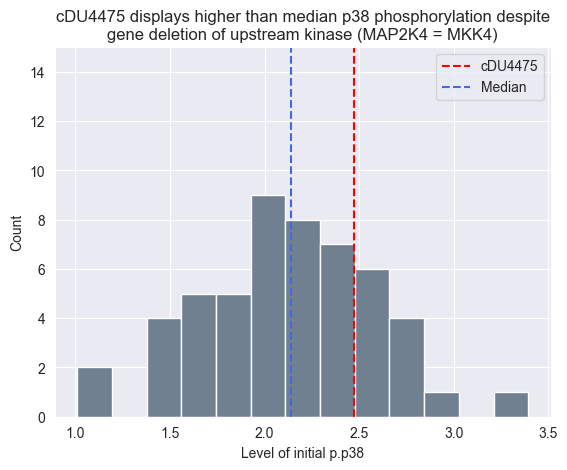

In [2]:
import matplotlib.pyplot as plt
init_phospho["p.p38"].hist(bins=13, color="slategray")
plt.axvline(init_phospho.loc["cDU4475", "p.p38"], color='red', ls='--', label='cDU4475')
plt.axvline(init_phospho["p.p38"].median(), color="royalblue", ls="--", label='Median')
plt.xlabel("Level of initial p.p38")
plt.ylabel("Count")
plt.ylim([0, 15])
plt.legend()
plt.title("cDU4475 displays higher than median p38 phosphorylation despite\ngene deletion of upstream kinase (MAP2K4 = MKK4)");

In [3]:
# Compute correlation of 'p.p38' with all other columns
correlations = init_phospho.corr()['p.p38']

# Drop self-correlation
correlations = correlations.drop('p.p38')

# Display correlations sorted by strength (absolute value)
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

print(correlations_sorted.head(10))

p.MKK4         0.660879
p.MKK3.MKK6    0.627479
p.p90RSK       0.624405
p.PLCg2        0.572468
p.SRC          0.556731
p.ERK          0.534695
p.AMPK         0.521682
p.BTK          0.514123
p.MAP2K3       0.508792
p.JNK          0.475569
Name: p.p38, dtype: float64


<Axes: >

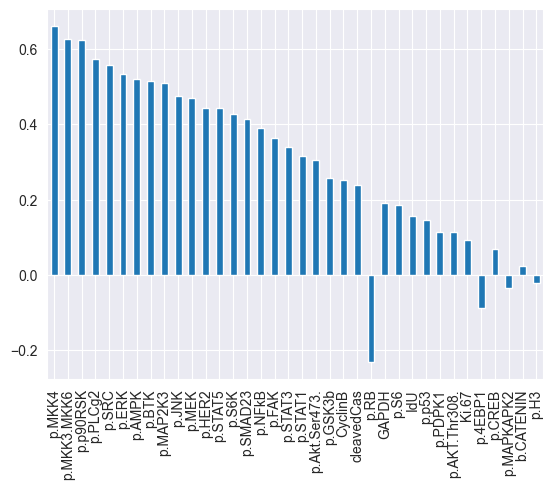

In [4]:
correlations_sorted.plot(kind='bar')

# Same condition, same timepoint correlations in full `cytof_dynamic`

In [5]:
import petab.v1 as petab
from dmm.feature_selection import harmonise_cytof_dynamic

meas_table = petab_base_files["measurement_table"]
obs_table = petab_base_files["observable_table"]
cytof_dynamic = meas_table[meas_table.measurementType == "cytof"]

# Split SIMULATION_CONDITION_ID and keep the stimulus info (0th is cell line, 1st is stimulus)
cytof_dynamic[petab.SIMULATION_CONDITION_ID] = cytof_dynamic[
    petab.SIMULATION_CONDITION_ID
].apply(lambda x: x.split("__")[1])

pivot_columns = (
    petab.OBSERVABLE_ID,
    petab.SIMULATION_CONDITION_ID,
    petab.TIME,
)

harmonised_cytof_dynamic = harmonise_cytof_dynamic(
    cytof_dynamic.pivot_table(
        index=petab.PREEQUILIBRATION_CONDITION_ID,  # i.e. the cell line
        columns=pivot_columns,
        # i.e. the observable/biomarkers in the case of cytof/proteomics and transcriptomics
        values=petab.MEASUREMENT,  # the actual measurement/signal
        aggfunc="mean",
    )
)

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_78198/2542270141.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cytof_dynamic[petab.SIMULATION_CONDITION_ID] = cytof_dynamic[


In [6]:
import pandas as pd

# Extract all unique (condition, time) pairs
all_conditions = sorted(set([(col[1], col[2]) for col in harmonised_cytof_dynamic.columns]))

correlation_records = []

for condition, t in all_conditions:
    # Select columns for this (condition, time)
    cols_ct = [col for col in harmonised_cytof_dynamic.columns if col[1] == condition and col[2] == t]
    df_ct = harmonised_cytof_dynamic[cols_ct]

    # Split into p.p38 vs others
    p38_cols = [col for col in cols_ct if col[0].startswith('p.p38')]
    other_cols = [col for col in cols_ct if col not in p38_cols]

    if not p38_cols or not other_cols:
        continue  # skip if one side missing

    for p38_col in p38_cols:
        p38_series = df_ct[p38_col]

        for other_col in other_cols:
            other_series = df_ct[other_col]
            corr = p38_series.corr(other_series)

            correlation_records.append({
                'condition': condition,
                'time': t,
                'p38_obs': p38_col[0],
                'other_obs': other_col[0],
                'correlation': corr
            })

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encounter

### Upstream kinases p.MKK3.MKK6 and p.MKK4 appear, as expected, among the top3 correlated features across conditions/treatments (EGF, EGF+iEGFR, EGF+iMEK) - accompanied/followed by p.p90RSK and p.JNK

In [7]:
correlation_df = pd.DataFrame(correlation_records)

# Group by (condition, p38_obs, other_obs)
grouped = correlation_df.groupby(['condition', 'p38_obs', 'other_obs'])

# Aggregate: mean corr & mean absolute corr
agg_df = grouped['correlation'].agg(['mean', lambda x: x.abs().mean()]).reset_index()
agg_df.columns = ['condition', 'p38_obs', 'other_obs', 'mean_corr', 'mean_abs_corr']

# Get top 5 correlated phospho-markers (across-time) per condition (EGF, iEGFR, iMEK)
top_corrs = (
    agg_df.sort_values(['condition', 'mean_abs_corr'], ascending=[True, False])
          .groupby('condition')
          .head(5)
          .reset_index(drop=True)
)
print(top_corrs.head(15))

   condition p38_obs    other_obs  mean_corr  mean_abs_corr
0        EGF   p.p38     p.p90RSK   0.710067       0.710067
1        EGF   p.p38  p.MKK3.MKK6   0.675771       0.675771
2        EGF   p.p38       p.MKK4   0.608884       0.608884
3        EGF   p.p38        p.JNK   0.599846       0.599846
4        EGF   p.p38        p.S6K   0.550008       0.550008
5      iEGFR   p.p38  p.MKK3.MKK6   0.711711       0.711711
6      iEGFR   p.p38     p.p90RSK   0.700830       0.700830
7      iEGFR   p.p38       p.MKK4   0.659161       0.659161
8      iEGFR   p.p38        p.JNK   0.637490       0.637490
9      iEGFR   p.p38        p.S6K   0.595593       0.595593
10      iMEK   p.p38  p.MKK3.MKK6   0.632962       0.632962
11      iMEK   p.p38        p.JNK   0.582709       0.582709
12      iMEK   p.p38       p.MKK4   0.580536       0.580536
13      iMEK   p.p38        p.SRC   0.566234       0.566234
14      iMEK   p.p38     p.p90RSK   0.529026       0.529026


# pHER2 and pMEK baseline values

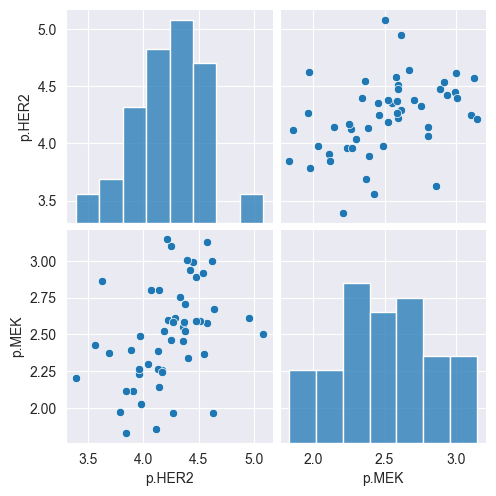

In [8]:
import seaborn as sns

sns.pairplot(init_phospho[["p.HER2", "p.MEK"]])

In [9]:
init_phospho[["p.HER2", "p.MEK"]]

,p.HER2,p.MEK
preequilibrationConditionId,,
c184A1,4.166056,2.258194
cBT20,4.475806,2.891350
cBT474,5.086383,2.503576
cBT549,4.114779,1.855541
cCAL148,4.266608,1.964273
cCAL851,4.136859,2.385287
cCAL51,4.627535,1.966395
cDU4475,4.551182,2.364454
cEFM192A,4.220376,2.596768


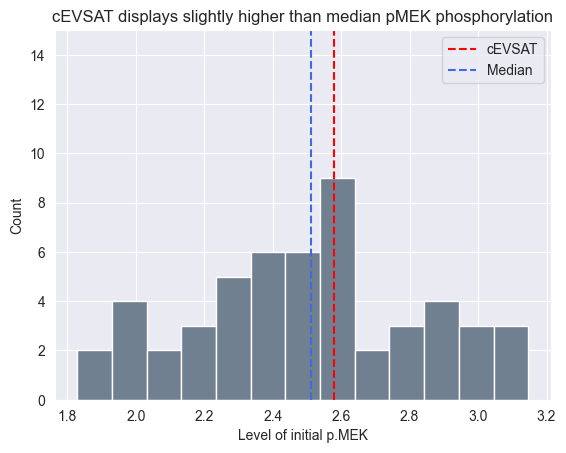

In [10]:
init_phospho["p.MEK"].hist(bins=13, color="slategray")
plt.axvline(init_phospho.loc["cEVSAT", "p.MEK"], color='red', ls='--', label='cEVSAT')
plt.axvline(init_phospho["p.MEK"].median(), color="royalblue", ls="--", label='Median')
plt.xlabel("Level of initial p.MEK")
plt.ylabel("Count")
plt.ylim([0, 15])
plt.legend()
plt.title("cEVSAT displays slightly higher than median pMEK phosphorylation");

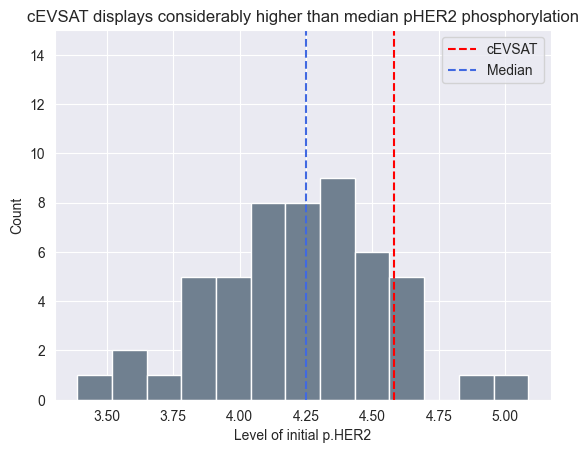

In [11]:
init_phospho["p.HER2"].hist(bins=13, color="slategray")
plt.axvline(init_phospho.loc["cEVSAT", "p.HER2"], color='red', ls='--', label='cEVSAT')
plt.axvline(init_phospho["p.HER2"].median(), color="royalblue", ls="--", label='Median')
plt.xlabel("Level of initial p.HER2")
plt.ylabel("Count")
plt.ylim([0, 15])
plt.legend()
plt.title("cEVSAT displays considerably higher than median pHER2 phosphorylation");

In [12]:
init_phospho[["p.HER2", "p.MEK"]].corr()

,p.HER2,p.MEK
p.HER2,1.000000,0.397204
p.MEK,0.397204,1.000000


In [13]:
init_phospho.corr()

,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,...,p.S6,p.S6K,p.SMAD23,p.SRC,p.STAT1,p.STAT3,p.STAT5,p.p38,p.p53,p.p90RSK
CyclinB,1.000000,0.172034,0.603407,0.642346,0.128498,0.277140,0.365452,0.205725,0.244113,0.189873,...,0.191970,0.034815,0.248929,0.087175,0.079869,-0.072833,-0.257695,0.252274,0.142209,0.141148
GAPDH,0.172034,1.000000,-0.095413,0.368834,0.696955,0.118829,0.419705,0.030667,0.274191,0.127896,...,0.406646,0.401168,0.257115,0.058431,0.222305,0.174782,0.078577,0.191839,0.040692,0.194440
IdU,0.603407,-0.095413,1.000000,0.367587,-0.208265,-0.146980,-0.049210,0.016720,-0.100008,0.272016,...,0.169461,0.014564,-0.160130,-0.040878,-0.090208,0.029457,-0.061235,0.155013,0.011005,0.105179
Ki.67,0.642346,0.368834,0.367587,1.000000,0.163537,0.164091,0.294942,0.065099,0.152956,0.118089,...,0.139485,0.085854,0.060190,0.060540,0.076983,0.059494,-0.103877,0.091337,0.009533,0.064921
b.CATENIN,0.128498,0.696955,-0.208265,0.163537,1.000000,0.149082,0.425111,-0.010246,0.272630,0.018574,...,0.065936,0.213308,0.331836,0.152649,0.207691,0.033413,-0.104755,0.023106,0.002415,-0.047425
cleavedCas,0.277140,0.118829,-0.146980,0.164091,0.149082,1.000000,0.110987,0.182968,0.471383,-0.200217,...,-0.058142,-0.165185,0.433737,0.199617,0.184741,0.012485,-0.088707,0.239457,-0.062974,-0.178840
p.4EBP1,0.365452,0.419705,-0.049210,0.294942,0.425111,0.110987,1.000000,0.147425,0.254248,0.175402,...,0.041058,0.229117,0.149501,0.036040,0.249375,-0.163888,-0.031355,-0.088238,0.388688,-0.007584
p.AKT.Thr308.,0.205725,0.030667,0.016720,0.065099,-0.010246,0.182968,0.147425,1.000000,0.061684,0.512458,...,0.075874,0.248218,0.492316,0.189955,0.135054,0.109758,0.203888,0.113202,0.129376,0.239131
p.AMPK,0.244113,0.274191,-0.100008,0.152956,0.272630,0.471383,0.254248,0.061684,1.000000,0.123053,...,0.065417,0.373014,0.463353,0.212226,0.283280,0.078540,0.149093,0.521682,0.251528,0.199180
p.Akt.Ser473.,0.189873,0.127896,0.272016,0.118089,0.018574,-0.200217,0.175402,0.512458,0.123053,1.000000,...,0.169975,0.520875,0.037108,0.194295,0.156982,0.080632,0.316497,0.306311,0.301171,0.434246


## Inspect distribution of mutations across input feature pairs

In [14]:
from cellosaurus_utils import *

_, seqvar_df = get_cell_line_cellosaurus_annotations(file_dir=features_dir)

File 'cellosaurus.txt' already exists in /Users/fabring/Desktop/DeepMechanisticModels/features_newmech. Skipping download.


In [15]:
init_phospho_ordered = init_phospho.sort_index()
assert all(seqvar_df.index.values == init_phospho_ordered.index.values)

In [16]:
annotated_init_phospho = init_phospho_ordered.merge(seqvar_df.reset_index().rename(columns={"cell_line": "preequilibrationConditionId"}), on="preequilibrationConditionId")

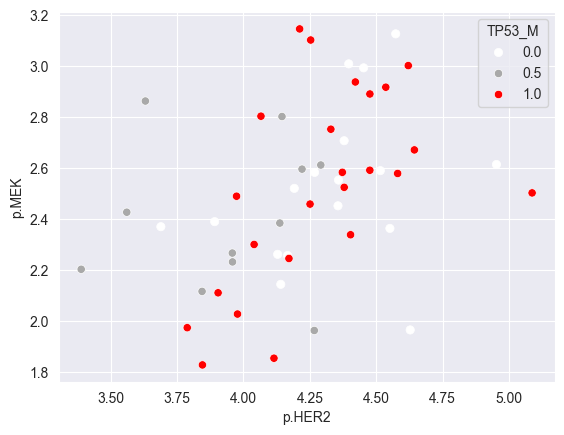

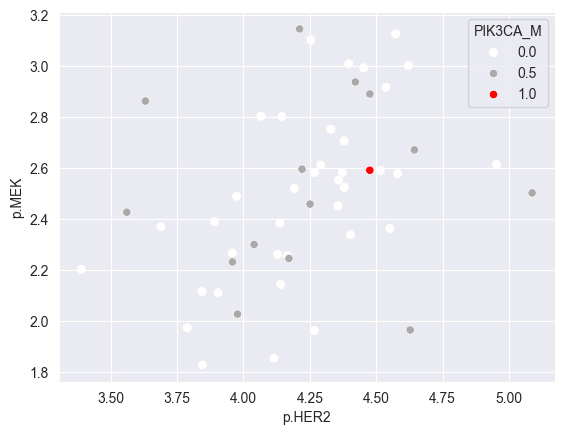

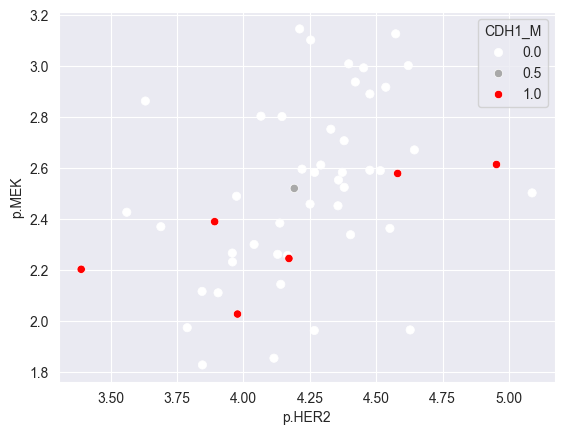

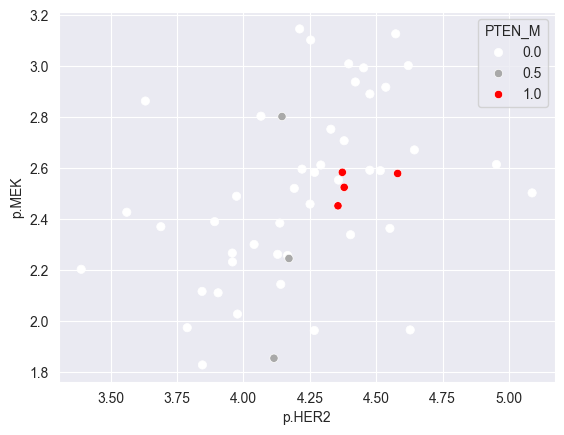

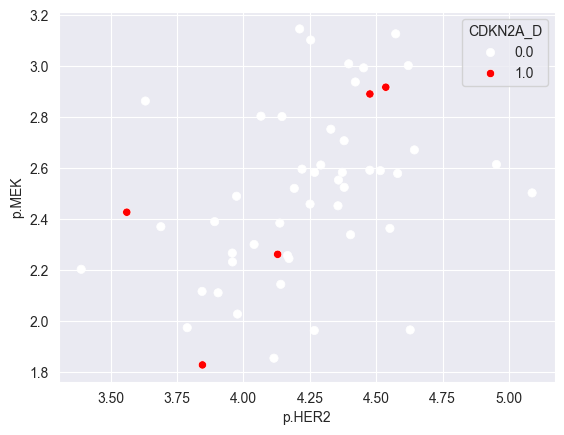

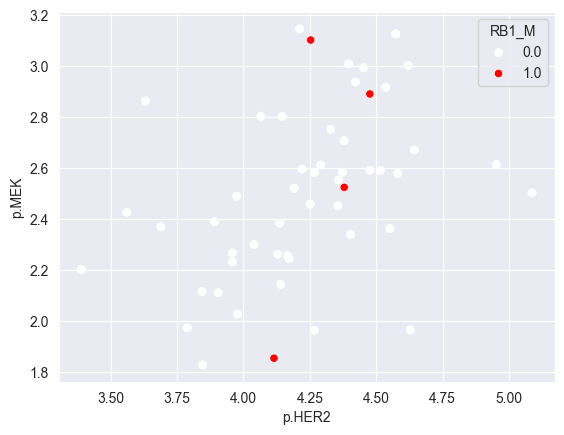

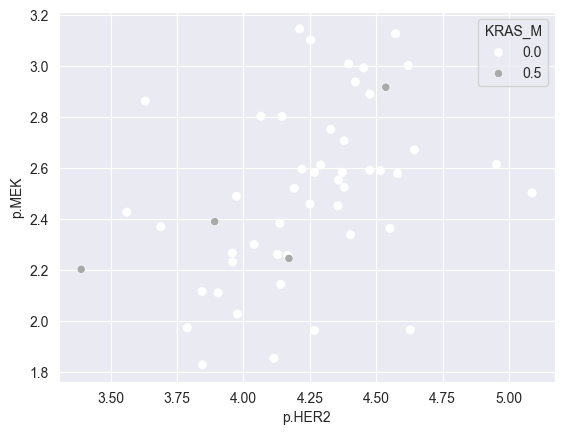

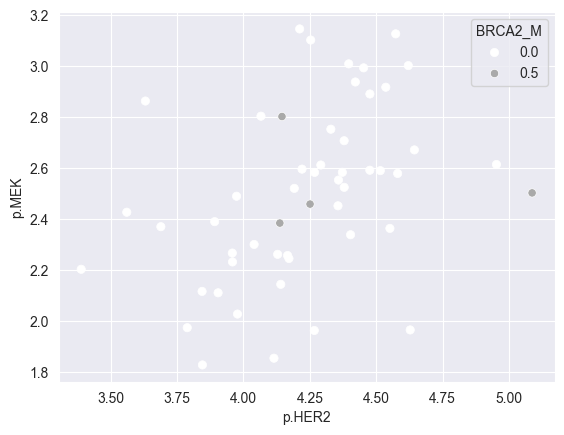

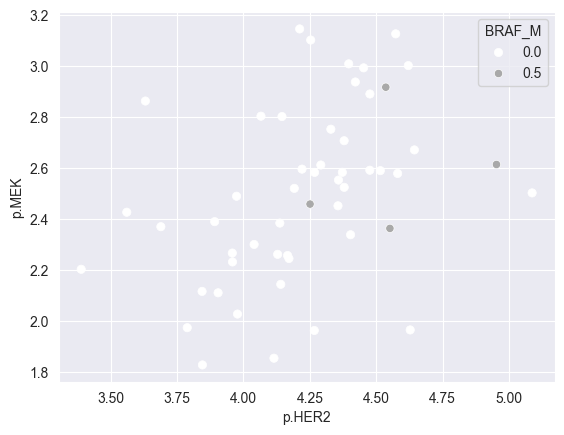

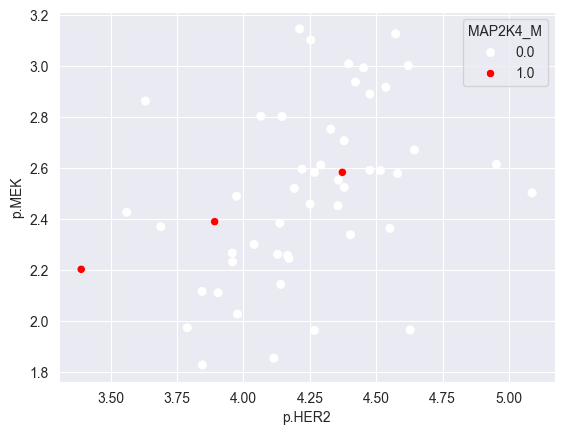

In [17]:
for hue_col in ['TP53_M', 'PIK3CA_M', 'CDH1_M', 'PTEN_M', 'CDKN2A_D', 'RB1_M', 'KRAS_M', 'BRCA2_M', 'BRAF_M', 'MAP2K4_M']:
    sns.scatterplot(
        annotated_init_phospho,
        x="p.HER2",
        y="p.MEK",
        hue=hue_col,
        palette={0: "white", 0.5: "darkgray", 1: "red"}
    )
    plt.show()

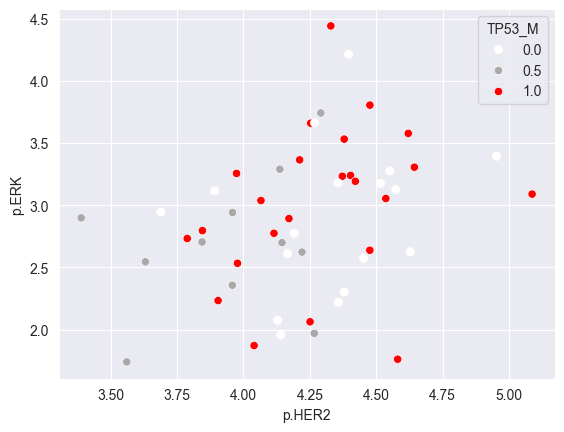

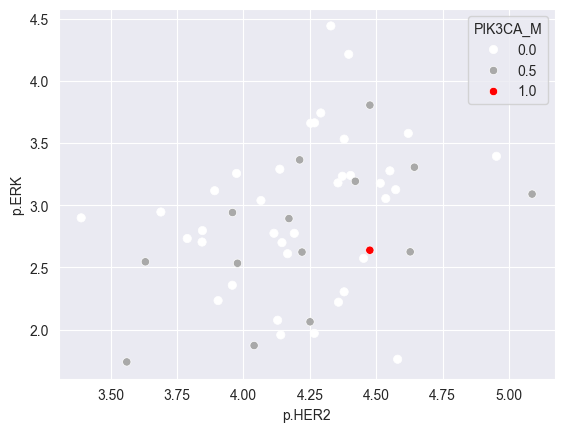

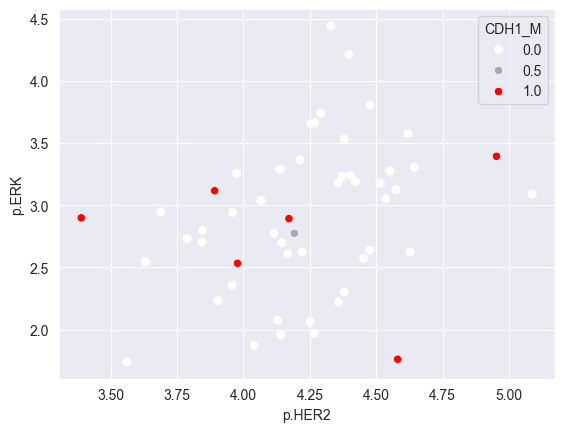

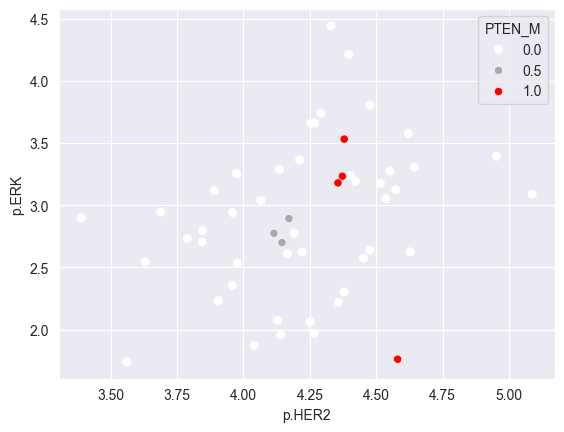

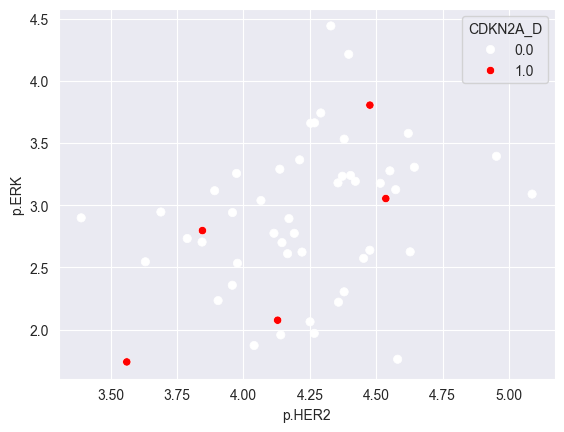

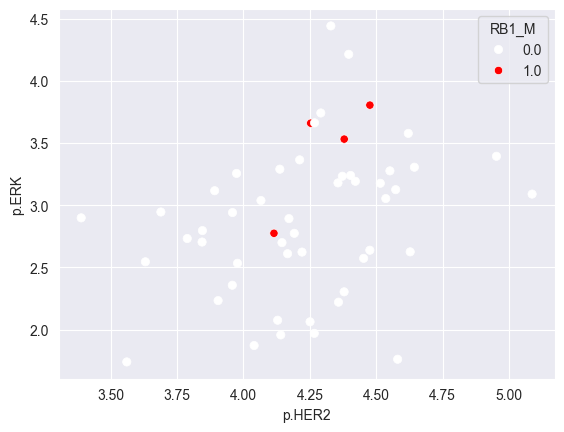

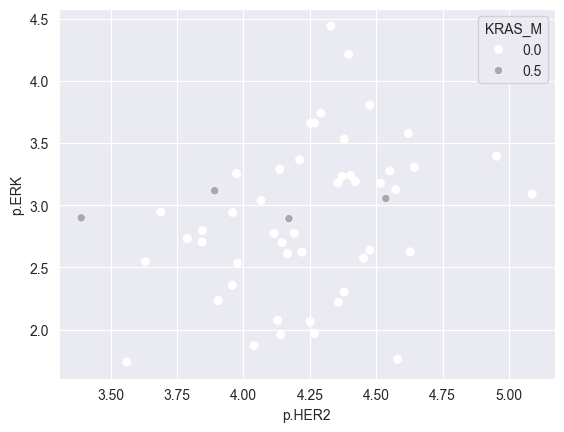

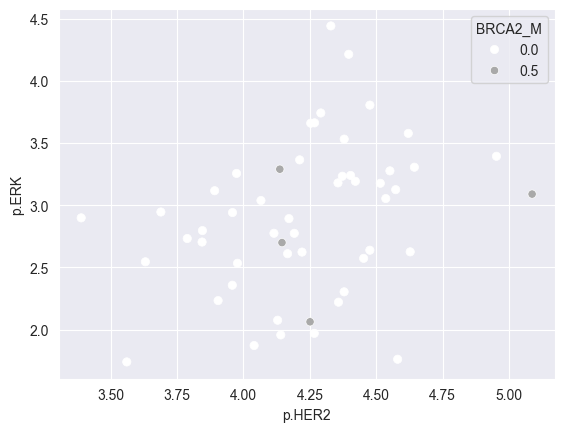

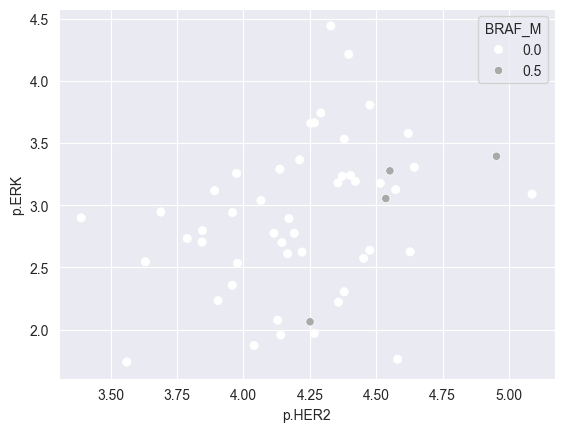

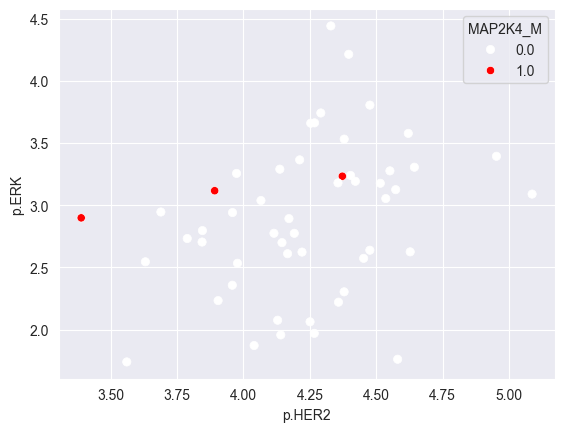

In [18]:
for hue_col in ['TP53_M', 'PIK3CA_M', 'CDH1_M', 'PTEN_M', 'CDKN2A_D', 'RB1_M', 'KRAS_M', 'BRCA2_M', 'BRAF_M', 'MAP2K4_M']:
    sns.scatterplot(
        annotated_init_phospho,
        x="p.HER2",
        y="p.ERK",
        hue=hue_col,
        palette={0: "white", 0.5: "darkgray", 1: "red"}
    )
    plt.show()

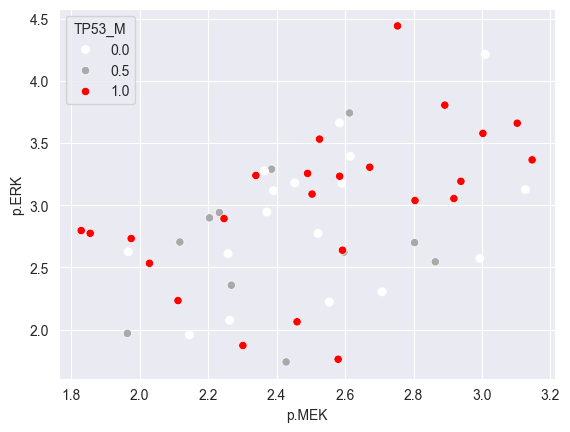

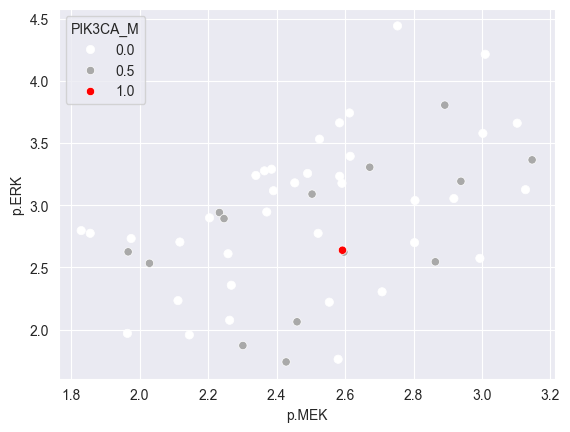

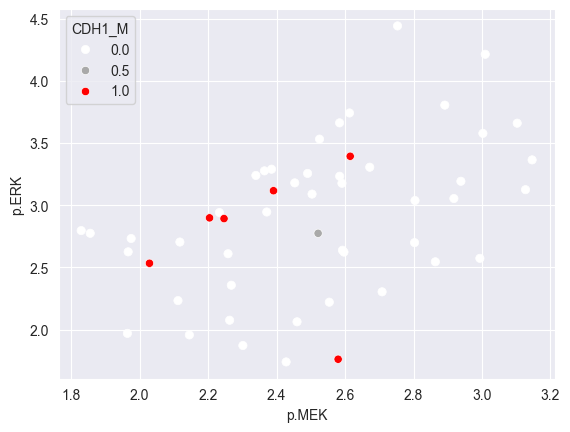

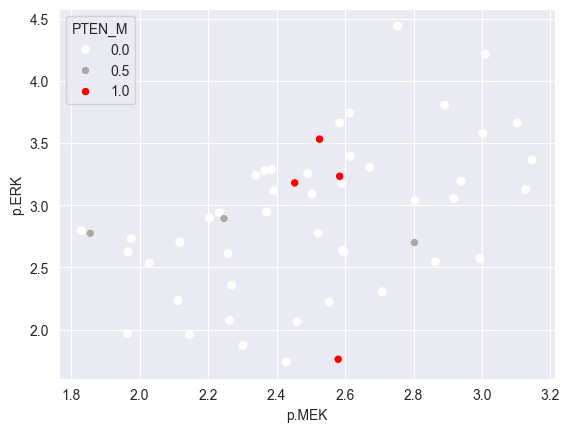

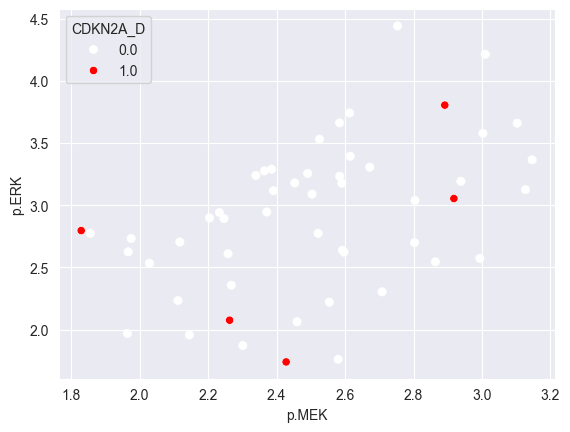

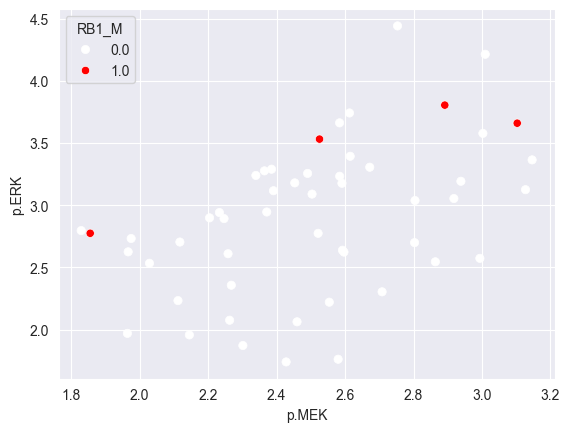

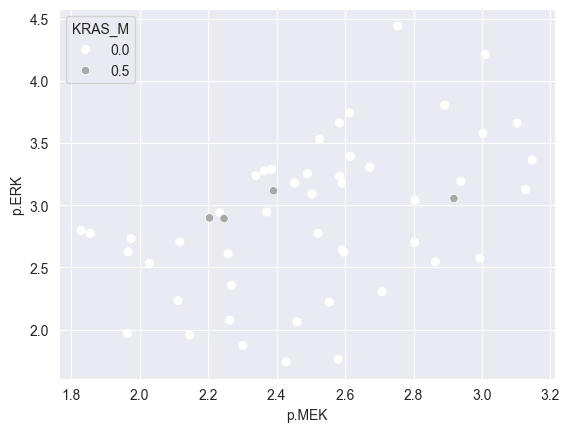

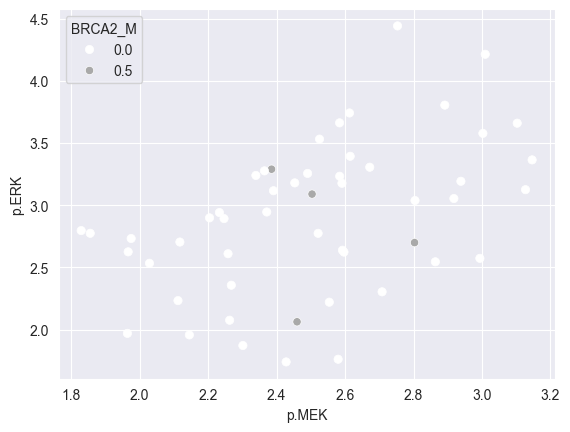

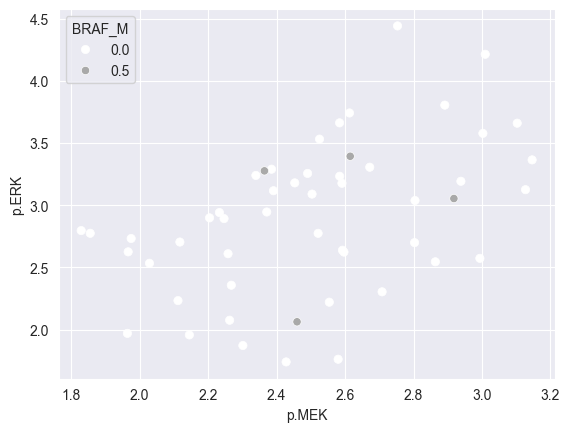

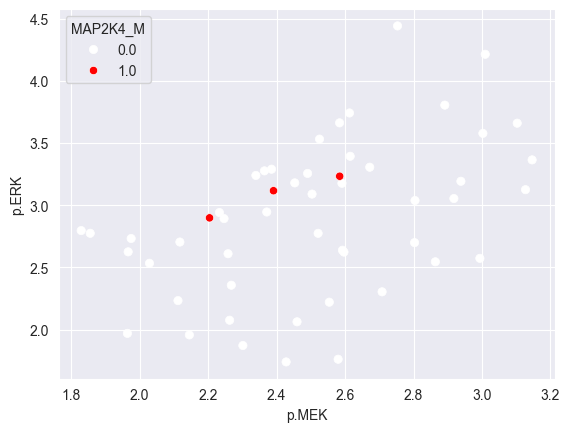

In [19]:
for hue_col in ['TP53_M', 'PIK3CA_M', 'CDH1_M', 'PTEN_M', 'CDKN2A_D', 'RB1_M', 'KRAS_M', 'BRCA2_M', 'BRAF_M', 'MAP2K4_M']:
    sns.scatterplot(
        annotated_init_phospho,
        x="p.MEK",
        y="p.ERK",
        hue=hue_col,
        palette={0: "white", 0.5: "darkgray", 1: "red"}
    )
    plt.show()

## Same annotation with PCA-ed `cytof_dynamic`

In [20]:
full_phospho, features_all, _, _ = load_data(
    contextualization="cytof_dynamic",
    samples=samples_all,
    features=None,
    **petab_base_files,
)
full_phospho.sort_index(inplace=True)

In [21]:
markers = set([i[0] for i in full_phospho.columns])
markers

{'pERBB2_Y1248_obs', 'pERK_Y204_obs', 'pMEK_S222_obs'}

In [22]:
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

marker_dfs = []
for marker in markers:
    sub_df = full_phospho[
        [i for i in full_phospho.columns if i[0] == marker]
    ]
    pca = PCA(n_components=1)
    knn = KNNImputer()
    knn.fit(sub_df)
    pca.fit(
        knn.transform(sub_df.values)
    )

    marker_dfs.append(
        pd.DataFrame(
            pca.transform(
                knn.transform(sub_df.values)
            ),
            index=sub_df.index,
            columns=[marker]
        )
    )

In [23]:
pca_full_phospho = pd.concat(marker_dfs, axis=1)

In [24]:
annotated_pca_full_phospho = pca_full_phospho.merge(seqvar_df.reset_index().rename(columns={"cell_line": "preequilibrationConditionId"}), on="preequilibrationConditionId")

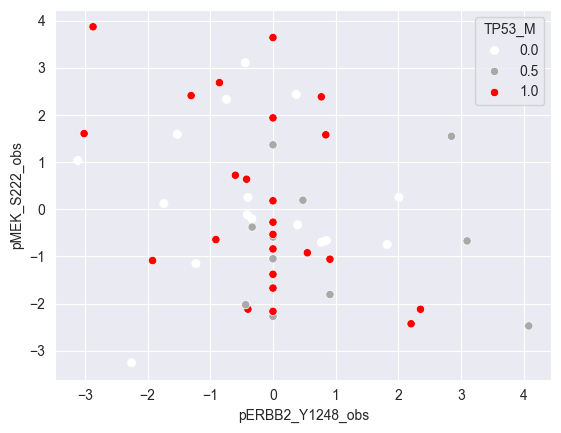

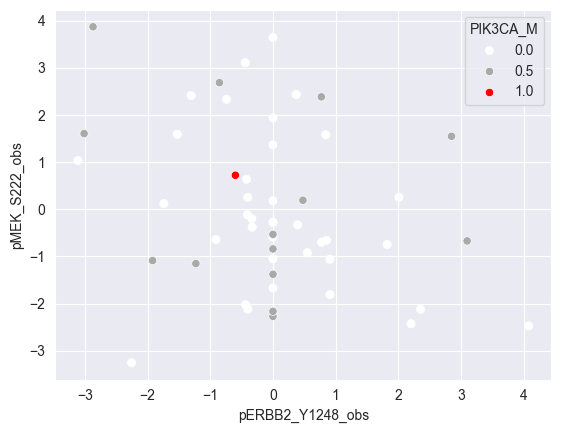

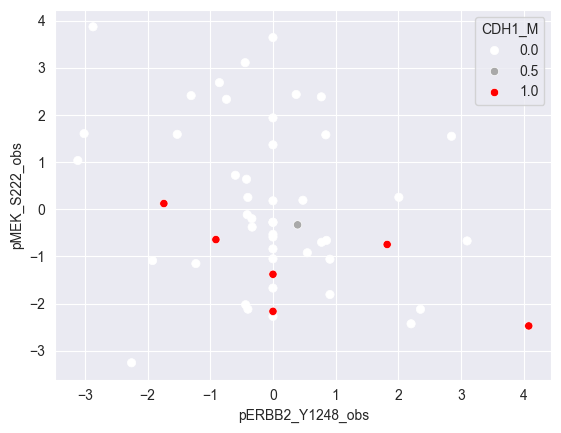

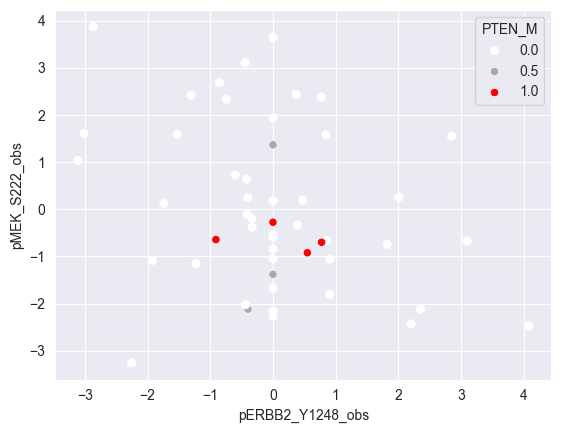

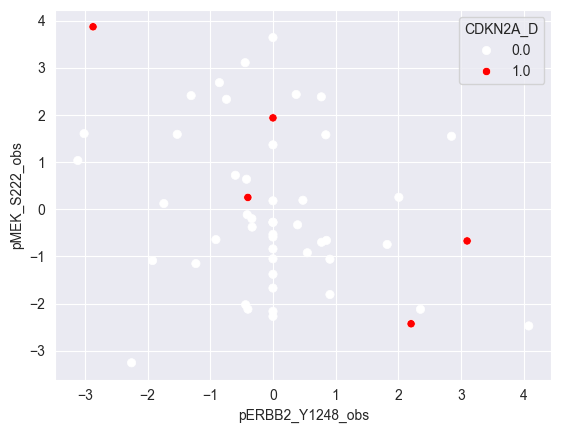

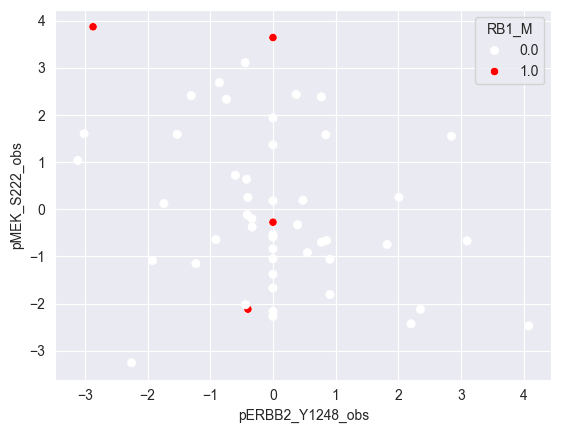

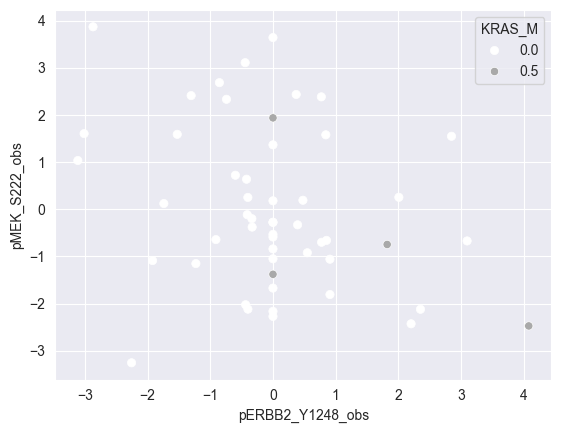

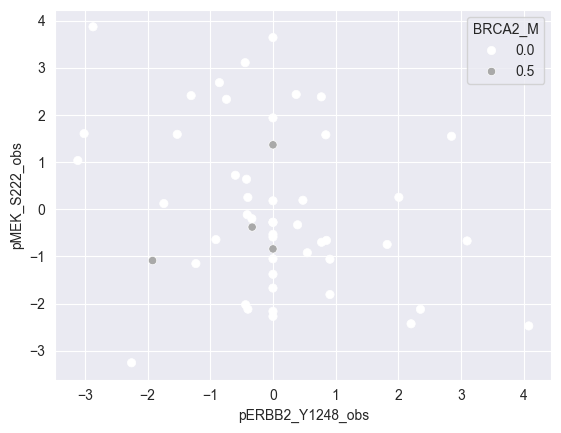

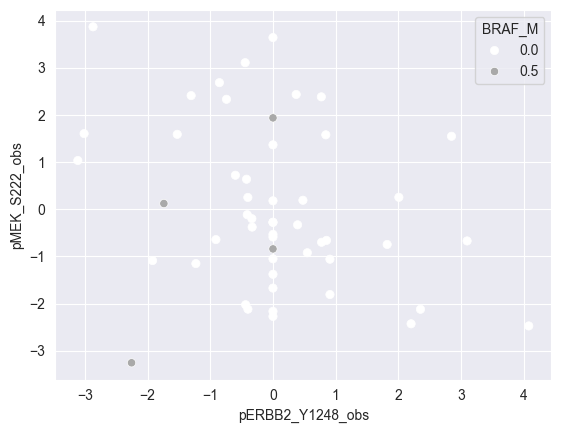

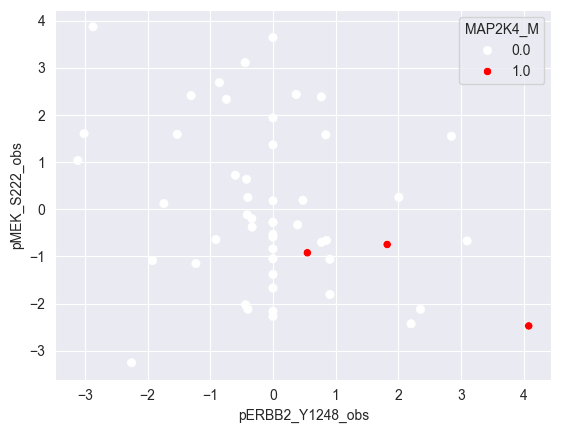

In [25]:
for hue_col in ['TP53_M', 'PIK3CA_M', 'CDH1_M', 'PTEN_M', 'CDKN2A_D', 'RB1_M', 'KRAS_M', 'BRCA2_M', 'BRAF_M', 'MAP2K4_M']:
    sns.scatterplot(
        annotated_pca_full_phospho,
        x="pERBB2_Y1248_obs",
        y="pMEK_S222_obs",
        hue=hue_col,
        palette={0: "white", 0.5: "darkgray", 1: "red"}
    )
    plt.show()

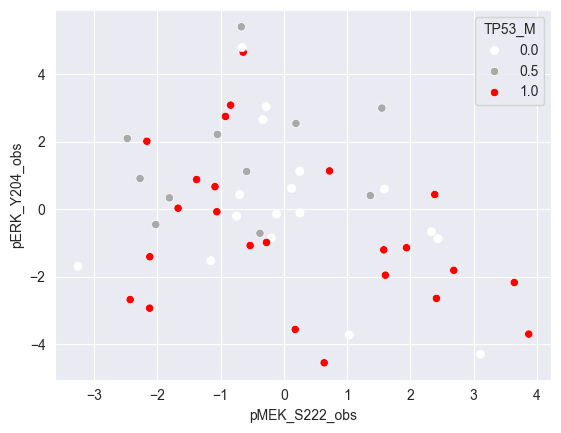

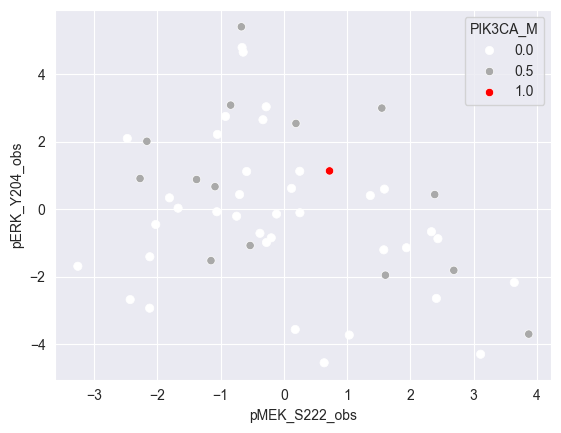

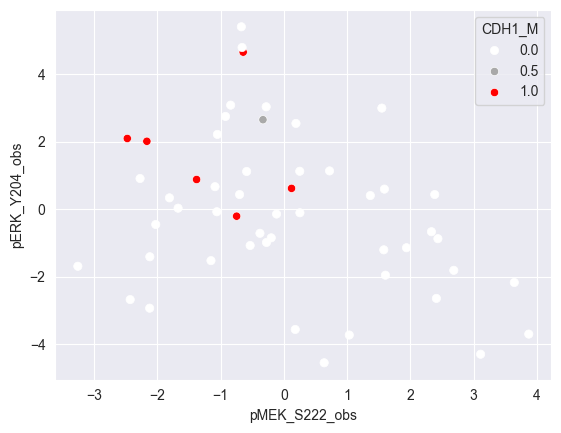

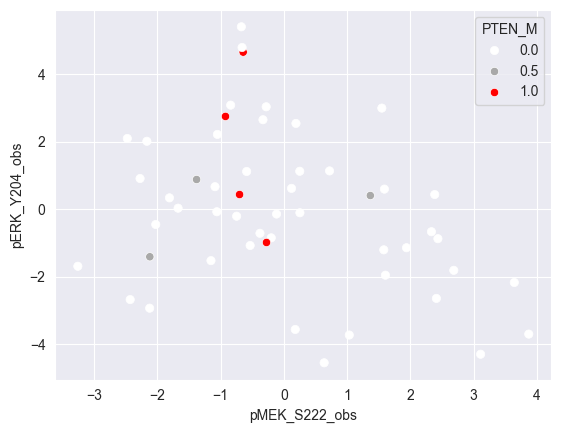

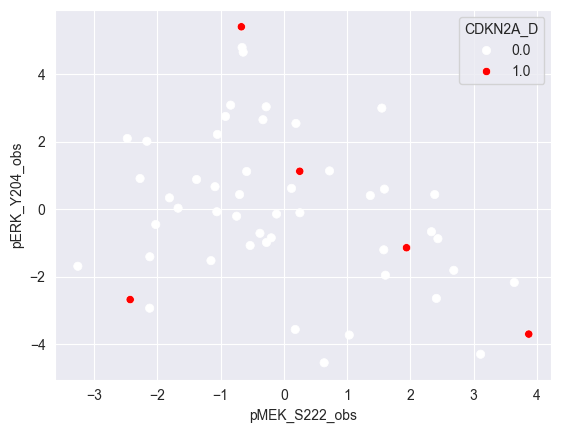

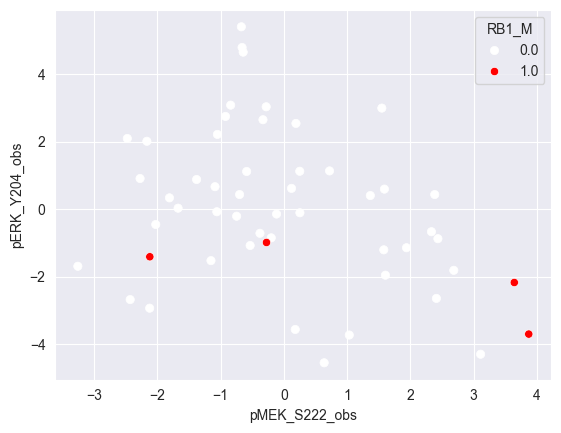

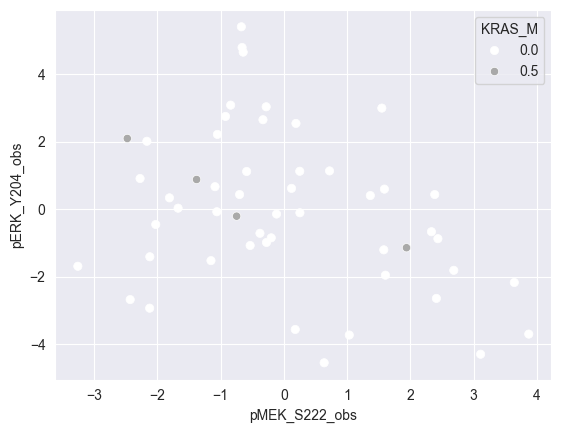

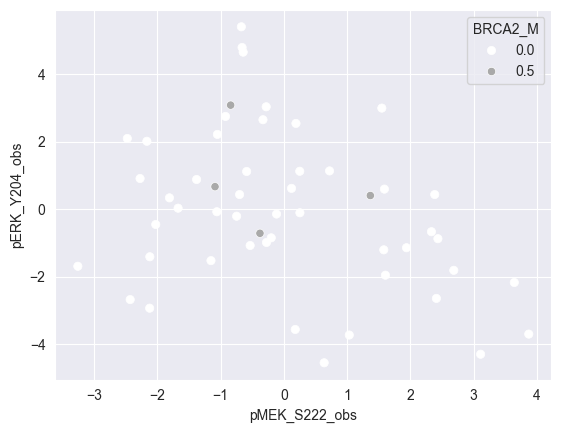

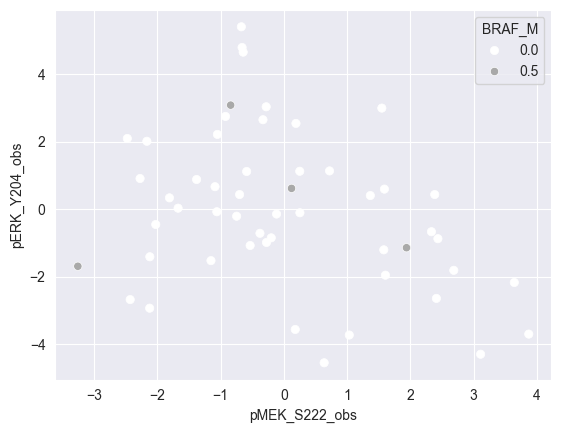

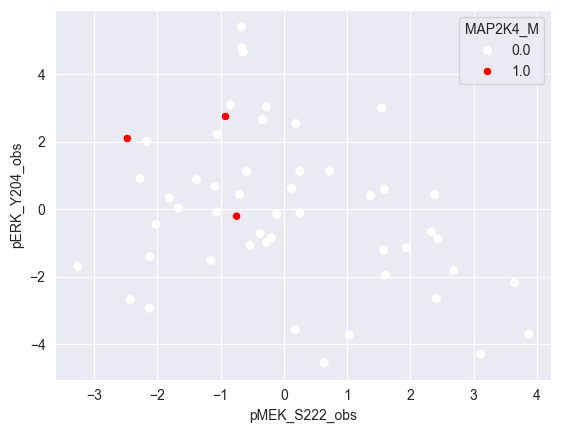

In [26]:
for hue_col in ['TP53_M', 'PIK3CA_M', 'CDH1_M', 'PTEN_M', 'CDKN2A_D', 'RB1_M', 'KRAS_M', 'BRCA2_M', 'BRAF_M', 'MAP2K4_M']:
    sns.scatterplot(
        annotated_pca_full_phospho,
        x="pMEK_S222_obs",
        y="pERK_Y204_obs",
        hue=hue_col,
        palette={0: "white", 0.5: "darkgray", 1: "red"}
    )
    plt.show()

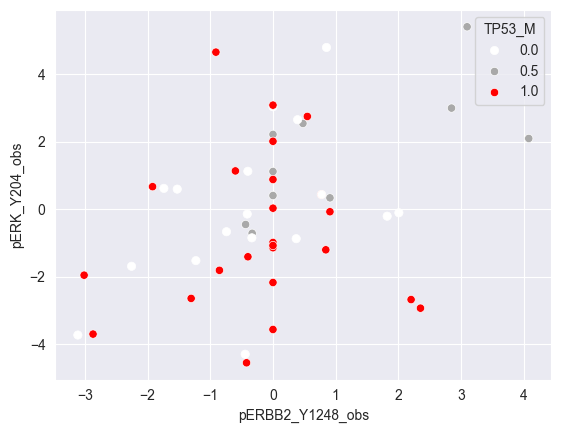

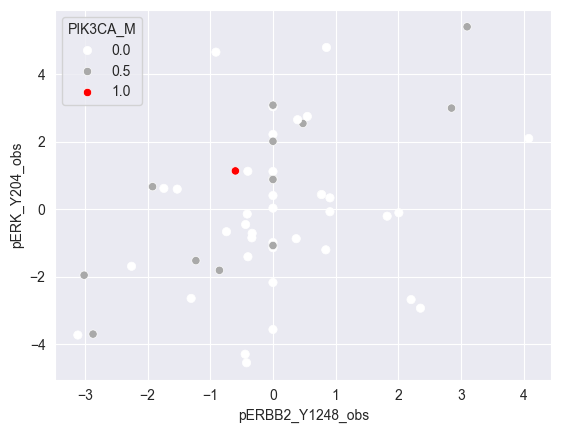

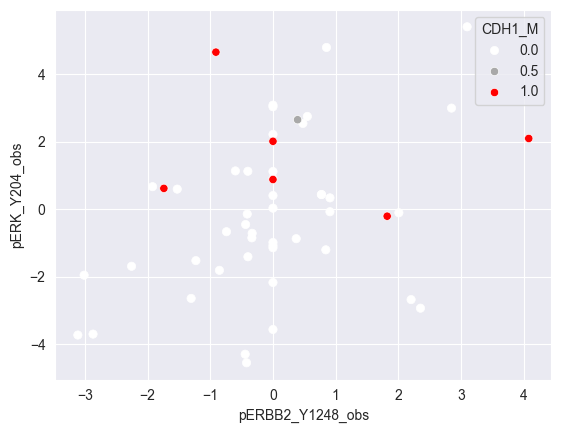

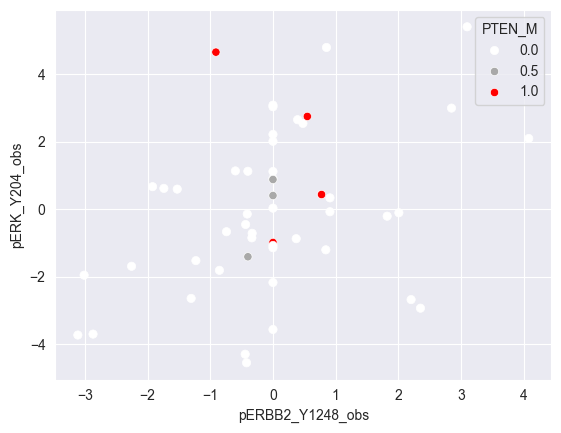

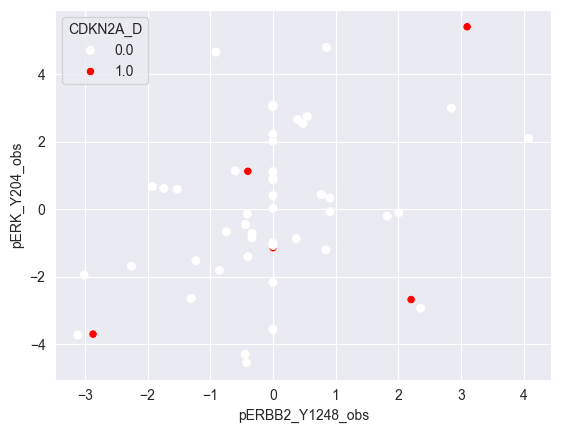

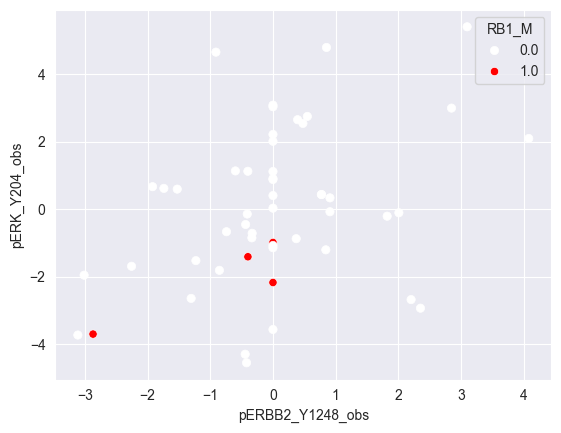

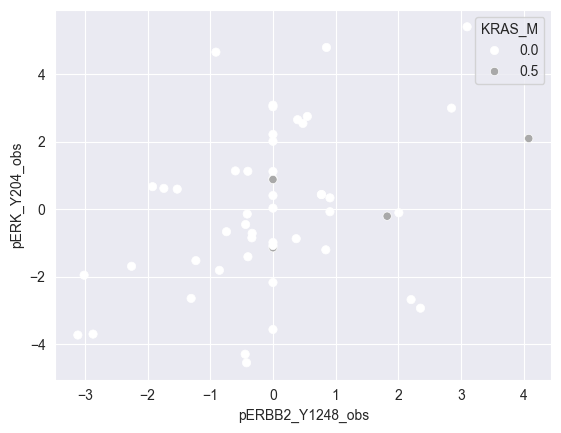

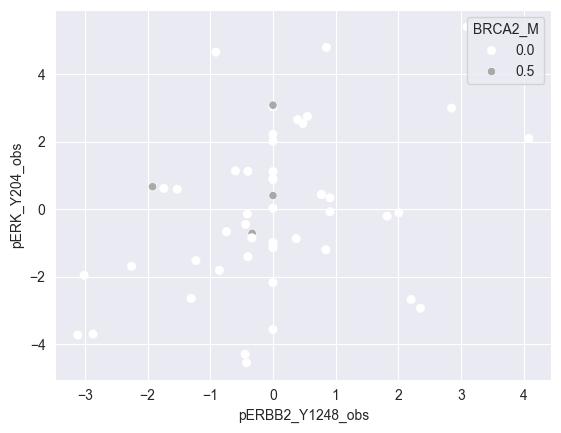

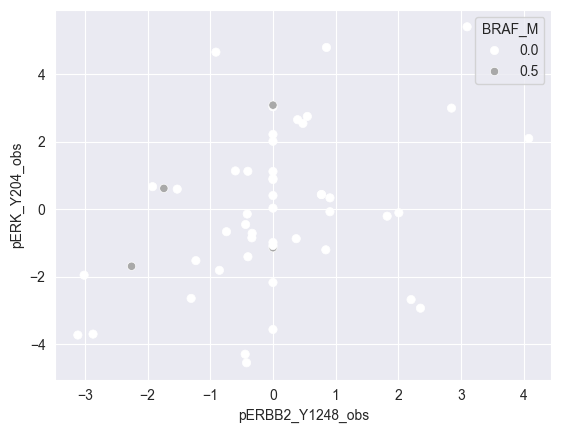

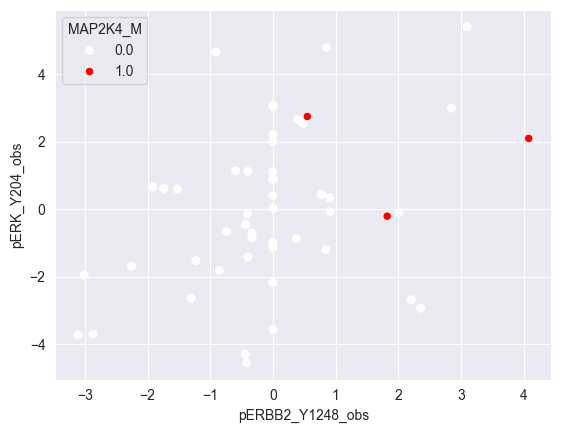

In [27]:
for hue_col in ['TP53_M', 'PIK3CA_M', 'CDH1_M', 'PTEN_M', 'CDKN2A_D', 'RB1_M', 'KRAS_M', 'BRCA2_M', 'BRAF_M', 'MAP2K4_M']:
    sns.scatterplot(
        annotated_pca_full_phospho,
        x="pERBB2_Y1248_obs",
        y="pERK_Y204_obs",
        hue=hue_col,
        palette={0: "white", 0.5: "darkgray", 1: "red"}
    )
    plt.show()